In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader,Dataset
import torch.functional as F
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import torch.optim as optim
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.preprocessing import MinMaxScaler


In [2]:

torch.manual_seed(42)

# 0 T-shirt/top
# 1 Trouser
# 2 Pullover
# 3 Dress
# 4 Coat
# 5 Sandal
# 6 Shirt
# 7 Sneaker
# 8 Bag
# 9 Ankle boot


In [3]:
df=pd.read_csv('/content/fashion-mnist_train.csv')
df

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,1,0,0,0,0,0,0,0,0,0,...,73,0,0,0,0,0,0,0,0,0
59997,8,0,0,0,0,0,0,0,0,0,...,160,162,163,135,94,0,0,0,0,0
59998,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
# df=df.sample(10000,random_state=32)

In [5]:
df['label'].nunique()

10

In [6]:
df['label'].unique()

array([2, 9, 6, 0, 3, 4, 5, 8, 7, 1])

In [7]:
df['label'].value_counts()

,count
label,
2,6000
9,6000
6,6000
0,6000
3,6000
4,6000
5,6000
8,6000
7,6000


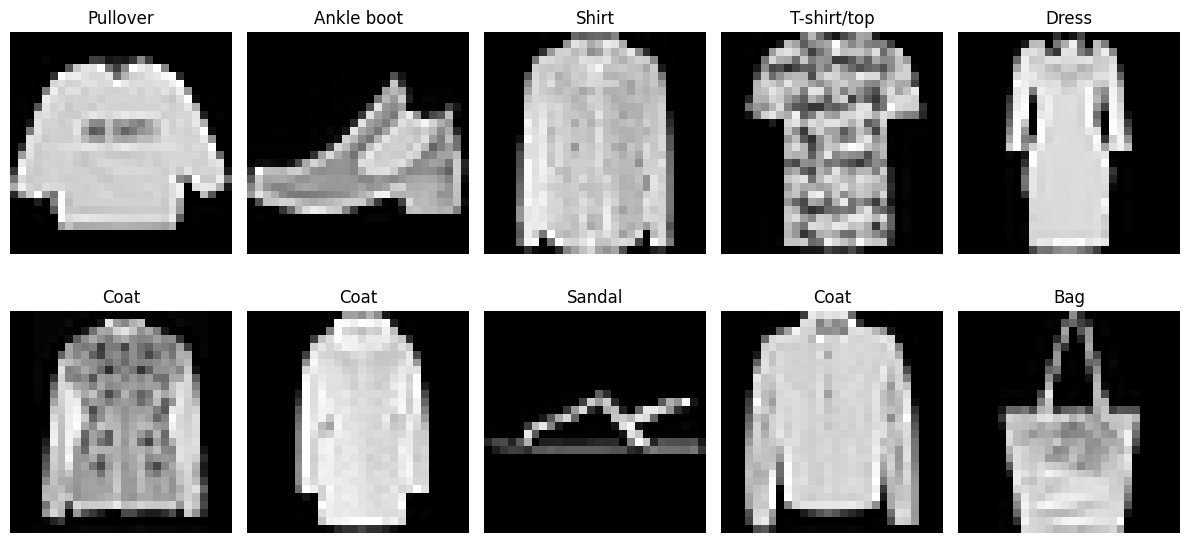

In [8]:
# Set up a grid with 2 rows and 5 columns
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.ravel()

# Fashion MNIST class labels in correct order
labels_map = {
    0: "T-shirt/top", 1: "Trouser", 2: "Pullover", 3: "Dress", 4: "Coat",
    5: "Sandal", 6: "Shirt", 7: "Sneaker", 8: "Bag", 9: "Ankle boot"
}

# Loop through the first 10 rows of the dataframe
for i in range(10):
    row = df.iloc[i]

    # Separate label from pixels (assumes 'label' is the column name)
    if 'label' in df.columns:
        label = row['label']
        pixels = row.drop('label').values
    else:
        label = None
        pixels = row.values

    # Reshape the flat 784 pixels into a 28x28 image matrix
    image = pixels.reshape(28, 28)

    # Plot the image
    axes[i].imshow(image, cmap='gray')
    axes[i].axis('off')

    # Add title if labels are available
    if label is not None:
        axes[i].set_title(labels_map.get(int(label), f"Class {label}"))

plt.tight_layout()
plt.show()


In [9]:
x=df.drop('label',axis=1)
y=df['label']

In [10]:
scaler=MinMaxScaler()
x=scaler.fit_transform(x)
x=pd.DataFrame(x)


In [11]:
x

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.019608,0.0,0.0,...,0.000000,0.000000,0.000000,0.117647,0.168627,0.000000,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.006098,0.008811,0.0,0.0,0.000000,0.0,0.0,...,0.011765,0.000000,0.000000,0.000000,0.000000,0.003922,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
59996,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.286275,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
59997,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.627451,0.635294,0.639216,0.529412,0.368627,0.000000,0.0,0.0,0.0,0.0
59998,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0


In [12]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [13]:
len(X_train),len(X_test)

(48000, 12000)

In [14]:
class CustomDataset(Dataset):
    def __init__(self, data, labels):
        self.data = data
        self.labels = labels
        self.data = torch.tensor(self.data.values, dtype=torch.float32)
        self.labels = torch.tensor(self.labels.values, dtype=torch.long)
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

In [15]:
batch_size=100

In [16]:
dataset = CustomDataset(X_train, y_train)
train_loader = DataLoader(dataset, batch_size=100, shuffle=True,num_workers=4)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [17]:
len(train_loader)

480

In [18]:
len(dataset)

48000

In [19]:
test_loader=DataLoader(CustomDataset(X_test,y_test),batch_size=100,shuffle=True,num_workers=4)

In [20]:
for x,y in train_loader:
  print(x.shape,y.shape)
  break

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


torch.Size([100, 784]) torch.Size([100])


In [21]:
class FashionMNIST(nn.Module):
    def __init__(self,features):
        super().__init__()
        self.model=nn.Sequential(
            nn.Linear(in_features=features,out_features=128),
            nn.ReLU(),
            nn.Dropout(p=0.4),
            nn.Linear(in_features=128,out_features=64),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(in_features=64,out_features=10)
        )

    def forward(self, x):
        return self.model(x)


In [22]:
epochs=100
lr=0.001

In [23]:
model=FashionMNIST(X_train.shape[1])
# model.to('cuda')


criterion=nn.CrossEntropyLoss()

optimizer=optim.Adam(model.parameters(),lr=lr)


In [24]:
print(model.parameters)

<bound method Module.parameters of FashionMNIST(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=10, bias=True)
  )
)>


In [25]:
for epoch in range(epochs):
    epoch_loss=0
    for data,labels in train_loader:
        # data=data.to('cuda')
        # labels=labels.to('cuda')
        output=model(data)
        loss=criterion(output,labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss+=loss.item()

    print(f'Epoch {epoch+1}/{epochs} Loss: {epoch_loss/len(train_loader)}')


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch 1/100 Loss: 0.776161979076763
Epoch 2/100 Loss: 0.5152824437245727
Epoch 3/100 Loss: 0.46245595437164105
Epoch 4/100 Loss: 0.4347085310767094
Epoch 5/100 Loss: 0.4146414975946148
Epoch 6/100 Loss: 0.3997633125943442
Epoch 7/100 Loss: 0.38949645552784207
Epoch 8/100 Loss: 0.3822144957569738
Epoch 9/100 Loss: 0.3719974344285826
Epoch 10/100 Loss: 0.36392422787224254
Epoch 11/100 Loss: 0.3578888363204896
Epoch 12/100 Loss: 0.35432804881905516
Epoch 13/100 Loss: 0.346215716501077
Epoch 14/100 Loss: 0.3436929691893359
Epoch 15/100 Loss: 0.338579350647827
Epoch 16/100 Loss: 0.3313432619906962
Epoch 17/100 Loss: 0.3289650815849503
Epoch 18/100 Loss: 0.3272591832714776
Epoch 19/100 Loss: 0.32357082879170773
Epoch 20/100 Loss: 0.32445666637892523
Epoch 21/100 Loss: 0.31869742140794793
Epoch 22/100 Loss: 0.3178010591926674
Epoch 23/100 Loss: 0.3130700757727027
Epoch 24/100 Loss: 0.3098761149837325
Epoch 25/100 Loss: 0.30462371685231726
Epoch 26/100 Loss: 0.3050161203679939
Epoch 27/100 Los

In [26]:
model.eval()

FashionMNIST(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [46]:
total=0
correct=0
i=2
with torch.no_grad():
    for data,labels in test_loader:
        output=model(data)

        _,predicted=torch.max(output.data,1)
        total+=labels.shape[0]
        correct+=(predicted==labels).sum().item()

accuracy=100*correct/total
print('Accuracy=',accuracy)

Accuracy= 89.225


In [30]:
len(test_loader)

120